🚀 ANIVIA RİSK RADARI: UÇTAN UCA OPTİMİZE MODEL


c:\Users\betul\Notes\ANIVIA\ybs-makine-ogrenmesi\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Optimize Karar Eşiği: 0.35
--------------------------------------------------
📊 NİHAİ OPTİMİZE SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      3664
           1       0.32      0.80      0.46       597

    accuracy                           0.74      4261
   macro avg       0.64      0.77      0.65      4261
weighted avg       0.87      0.74      0.78      4261



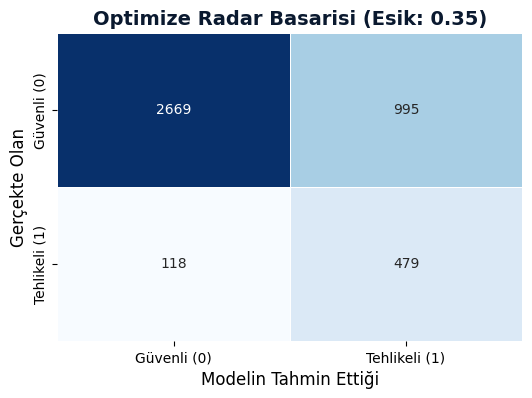

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("🚀 ANIVIA RİSK RADARI: UÇTAN UCA OPTİMİZE MODEL")
print("="*60)

# 1. Veriyi Okuma
df_oyunlar = pd.read_csv("../../data/processed/oyunlar_temiz.csv")

# 2. X (Girdi) ve y (Hedef) Ayrımı - Yaş ve Kategoriyi Saklıyoruz (Data Leakage Önlemi)
X_ham = df_oyunlar[['fiyat', 'platform', 'cihaz_turu']].copy()
y = df_oyunlar['tehlikeli_oyun'].copy()

# =====================================================================
# 3. Sektör Odaklı Zeki Veri Doldurma (F2P Mantığı)
# =====================================================================
# Önce PC/Konsol oyunlarını kendi akranlarının medyanıyla dolduruyoruz
X_ham['fiyat'] = X_ham.groupby(['platform', 'cihaz_turu'])['fiyat'].transform(lambda x: x.fillna(x.median()))
# Fiyatı hala eksik olanlar App Store (Mobil) oyunlarıdır, onları 0 (Bedava) yapıyoruz
X_ham['fiyat'] = X_ham['fiyat'].fillna(0)

# 4. Kategorik Verileri Sayısallaştırma (One-Hot Encoding)
X_encoded = pd.get_dummies(X_ham, columns=['platform', 'cihaz_turu'], drop_first=True)

# 5. Veriyi Eğitim ve Test Olarak İkiye Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 6. Ölçeklendirme (Sadece X için, fiyat farklılıklarını dengelemek adına)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 7. DENGELİ (BALANCED) MODEL EĞİTİMİ
# =====================================================================
# Tehlikeli (1) oyunları kaçırmaması için sınıfları ağırlıklandırıyoruz
rf_model_dengeli = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_dengeli.fit(X_train_scaled, y_train)

# =====================================================================
# 8. İLERİ DÜZEY OPTİMİZASYON: KARAR EŞİĞİ (THRESHOLD) AYARLAMA
# =====================================================================
# Modelin Olasılık Tahminlerini alıyoruz (:, 1 ifadesi Tehlikeli olma olasılığıdır)
y_olasiliklar = rf_model_dengeli.predict_proba(X_test_scaled)[:, 1]

# Eşiği %50'den %35'e düşürerek modeli daha şüpheci (Recall odaklı) yapıyoruz
yeni_esik = 0.35
y_pred_optimize = (y_olasiliklar >= yeni_esik).astype(int)

# 9. Başarı Metriklerini Raporlama
print(f"Optimize Karar Eşiği: {yeni_esik}")
print("-" * 50)
print("📊 NİHAİ OPTİMİZE SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, y_pred_optimize))

# 10. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
plt.figure(figsize=(6, 4))
cm_optimize = confusion_matrix(y_test, y_pred_optimize)
sns.heatmap(cm_optimize, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False,
            xticklabels=['Güvenli (0)', 'Tehlikeli (1)'], 
            yticklabels=['Güvenli (0)', 'Tehlikeli (1)'])
plt.title(f'Optimize Radar Basarisi (Esik: {yeni_esik})', fontsize=14, fontweight='bold', color='#0A192F')
plt.xlabel('Modelin Tahmin Ettiği', fontsize=12)
plt.ylabel('Gerçekte Olan', fontsize=12)
plt.show()

🚀 ANIVIA RİSK RADARI: XGBoost İLE MAKSİMUM OPTİMİZASYON


c:\Users\betul\Notes\ANIVIA\ybs-makine-ogrenmesi\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


XGBoost Optimize Karar Eşiği: 0.35
--------------------------------------------------
📊 NİHAİ XGBOOST SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83      3664
           1       0.33      0.85      0.48       597

    accuracy                           0.74      4261
   macro avg       0.65      0.79      0.65      4261
weighted avg       0.88      0.74      0.78      4261



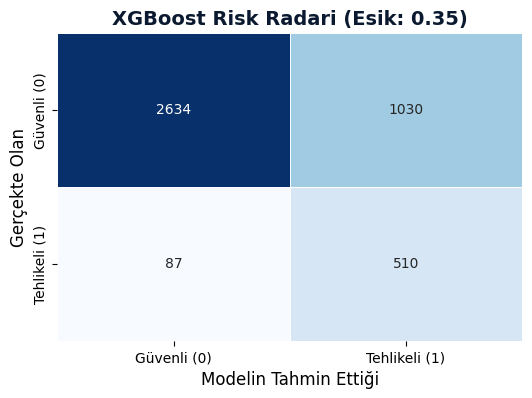

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb # YENİ MOTORUMUZ

print("="*60)
print("🚀 ANIVIA RİSK RADARI: XGBoost İLE MAKSİMUM OPTİMİZASYON")
print("="*60)

# 1. Veriyi Okuma (Aynı kalıyor)
df_oyunlar = pd.read_csv("../../data/processed/oyunlar_temiz.csv")

# 2. X (Girdi) ve y (Hedef) Ayrımı (Aynı kalıyor)
X_ham = df_oyunlar[['fiyat', 'platform', 'cihaz_turu']].copy()
y = df_oyunlar['tehlikeli_oyun'].copy()

# =====================================================================
# 3. SENİN VİZYONUN: Sektör Odaklı Zeki Veri Doldurma (F2P Mantığı) - KORUNDU!
# =====================================================================
X_ham['fiyat'] = X_ham.groupby(['platform', 'cihaz_turu'])['fiyat'].transform(lambda x: x.fillna(x.median()))
X_ham['fiyat'] = X_ham['fiyat'].fillna(0) # App Store 0 TL kuralı

# 4. Kategorik Verileri Sayısallaştırma (One-Hot Encoding) - KORUNDU!
X_encoded = pd.get_dummies(X_ham, columns=['platform', 'cihaz_turu'], drop_first=True)

# 5. Veriyi Eğitim ve Test Olarak İkiye Bölme - KORUNDU!
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 6. Ölçeklendirme - KORUNDU!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 7. XGBOOST MODEL EĞİTİMİ (YENİ VE DAHA GÜÇLÜ MOTOR)
# =====================================================================
# XGBoost için Dengesizlik Oranını (Scale Pos Weight) hesaplıyoruz: (Güvenli Sayısı / Tehlikeli Sayısı)
dengesizlik_orani = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# XGBoost Modelini kuruyoruz
xgb_model_dengeli = xgb.XGBClassifier(
    n_estimators=150,           # Biraz daha fazla ağaç
    scale_pos_weight=dengesizlik_orani, # Tehlikeli sınıfı önemseme katsayısı
    learning_rate=0.05,         # Daha yavaş ve dikkatli öğrenme
    max_depth=4,                # Ezberlemeyi önlemek için ağaç derinliğini kısıtlama
    random_state=42,
    eval_metric='logloss'
)

# Modeli Eğitiyoruz
xgb_model_dengeli.fit(X_train_scaled, y_train)

# =====================================================================
# 8. İLERİ DÜZEY OPTİMİZASYON: KARAR EŞİĞİ (THRESHOLD) AYARLAMA - KORUNDU!
# =====================================================================
# Modelin Olasılık Tahminlerini alıyoruz
y_olasiliklar = xgb_model_dengeli.predict_proba(X_test_scaled)[:, 1]

# Eşiği yine %35'te tutuyoruz (XGBoost'un bu eşiğe tepkisi çok daha keskin olacaktır)
yeni_esik = 0.35
y_pred_optimize = (y_olasiliklar >= yeni_esik).astype(int)

# 9. Başarı Metriklerini Raporlama
print(f"XGBoost Optimize Karar Eşiği: {yeni_esik}")
print("-" * 50)
print("📊 NİHAİ XGBOOST SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, y_pred_optimize))

# 10. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
plt.figure(figsize=(6, 4))
cm_optimize = confusion_matrix(y_test, y_pred_optimize)
sns.heatmap(cm_optimize, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False,
            xticklabels=['Güvenli (0)', 'Tehlikeli (1)'], 
            yticklabels=['Güvenli (0)', 'Tehlikeli (1)'])
plt.title(f'XGBoost Risk Radari (Esik: {yeni_esik})', fontsize=14, fontweight='bold', color='#0A192F')
plt.xlabel('Modelin Tahmin Ettiği', fontsize=12)
plt.ylabel('Gerçekte Olan', fontsize=12)
plt.show()

In [3]:
import joblib

print("="*60)
print("💾 NİHAİ MODELİ VE SCALER'I KAYDETME (STREAMLIT İÇİN)")
print("="*60)

# Modeli ve Scaler'ı doğrudan 'models' klasörüne kaydediyoruz
joblib.dump(xgb_model_dengeli, '../../models/anivia_risk_radari_xgb.pkl')
joblib.dump(scaler, '../../models/anivia_scaler.pkl')

print("✅ XGBoost Modeli ve Scaler başarıyla kaydedildi!")

💾 NİHAİ MODELİ VE SCALER'I KAYDETME (STREAMLIT İÇİN)
✅ XGBoost Modeli ve Scaler başarıyla kaydedildi!
